# (RK) ALS SC-Xenium — MN-corrected gene-comparison heatmaps

**Gene-gene Spearman correlation computed *within the actual annotated motor neurons* (`obs['is_MN']`), NOT within the old STMN2/MNX1/BCL6 top-30% expression gates.**

- **Object:** `/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/SC_MNcorrected_h5ads/ALS_SCXenium_MNcorrected_gausss_concatenated_offset_allsamples_preQC_20260706.h5ad`
- **Shape:** ~1,885,626 cells x 480 genes (PRE-QC). `X` = raw counts; layers built in-notebook.
- **MN mask:** `obs['is_MN']` (bool; True = 11,200 MNs). The substantive change vs the legacy gated notebook is replacing the STMN2 top-30% gate with this MN mask; the legacy **c9-vs-control** delta is reproduced (secondary figure) and an abstract-aligned **ALS(sporadic+c9)-vs-control** delta is added as the primary.
- **Kernel:** `rk_spatial_min` (python 3.11.14).
- **Provenance / date:** built 2026-07-08. Deliverable dir: `/home/rodrigok/Notebooks/Spatial_MN_correct/`.

This notebook reproduces the correlation-heatmap panels of the legacy
`(RK)ALS_SCXenium_gated_genecomparisons.ipynb` (its cell 8 / cell 9), reusing the
same machinery (`as1d`, `resolve_gene`, `get_vec_from_layer`, `bh_fdr`, `mat_from`,
`draw_heat`, the both-groups-`q<0.05` & `|Delta|>=0.05` star rule, the `n>=30` min-n
guard, and the combined / p-value / heatmap-only CSV exports). The QC cell is
deliberately omitted.


In [1]:
# Env guard: drop any user-site (~/.local) paths so the kernel's pinned stack wins.
import sys
sys.path[:] = [p for p in sys.path if ".local/lib" not in p]

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, spearmanr

print("scanpy", sc.__version__)
print("anndata", ad.__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)


/local/scratch/rodrigok/slrmtmp.51996590/ipykernel_286047/2443459532.py:12: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


scanpy 1.11.5
anndata 0.12.0
numpy 2.3.5 | pandas 2.3.3


In [2]:
# Load the combined MN-corrected object and fail loudly if it is not what we expect.
OBJ_PATH = "/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/SC_MNcorrected_h5ads/ALS_SCXenium_MNcorrected_gausss_concatenated_offset_allsamples_preQC_20260706.h5ad"

adata = sc.read_h5ad(OBJ_PATH)
print("loaded:", adata.shape)

# Shape / schema asserts (>1.8e6 cells, 480 genes, required obs + genes present).
assert adata.n_obs > 1.8e6, f"unexpected n_obs = {adata.n_obs} (expected > 1.8e6)"
assert adata.n_vars == 480, f"unexpected n_vars = {adata.n_vars} (expected 480)"
for _c in ["is_MN", "status"]:
    assert _c in adata.obs.columns, f"missing obs column: {_c}"

corr_genes = ["CCDC146", "STMN2", "CE_STMN2", "UNC13A", "CE_UNC13A", "TARDBP"]
_missing = [g for g in corr_genes if g not in adata.var_names]
assert not _missing, f"missing corr genes in var_names: {_missing}"

# is_MN should be boolean-like and match the known MN count.
adata.obs["is_MN"] = adata.obs["is_MN"].astype(bool)
print("is_MN True count:", int(adata.obs["is_MN"].sum()))
print("status value counts:\n", adata.obs["status"].astype(str).value_counts())
print("all required genes present.")


loaded: (1885626, 480)
is_MN True count: 11200
status value counts:
 status
control     924844
sporadic    536762
c9          424020
Name: count, dtype: int64
all required genes present.


In [3]:
# Build layers. X is raw counts; there are no layers on disk.
#
# Justification (does NOT breach guardrail G1 / Bhuva 2024): per-cell
# normalize_total removes the cell-size / total-count confound that would
# otherwise inflate all-vs-all positive correlation among MNs (large somata
# carry more of every transcript). Spearman is rank-based and invariant to any
# monotone per-gene transform, so the target_sum constant and log1p do NOT
# change any rho value; they only make 'lognorm' a conventional, reusable layer.
# G1 bans library-size normalisation before niche/domain/clustering (it erases
# the WM/GM total-detections contrast). Here we compute per-cell correlations
# inside a FIXED MN set, where removing library size is the correct move.
#
# NOTE (citation caveat): SPATIAL_KB is absent on this box, so the G1 reasoning
# above is grounded in the distilled domain_seed (Bhuva 2024 library-size
# guardrail; Salas 2025 segmentation), not a fresh grep of the corpus.

adata.layers["counts"] = adata.X.copy()
adata.uns.pop("log1p", None)                     # allow safe cell re-run (else log1p may skip)
sc.pp.normalize_total(adata, target_sum=1e4)   # CP10K per-cell library-size scaling
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()
adata.X = adata.layers["counts"].copy()          # restore X to raw counts (hygiene)

print("layers:", list(adata.layers.keys()))
print("X restored to raw counts:", bool(np.all(adata.X.data == np.round(adata.X.data))) if hasattr(adata.X, "data") else "dense")


/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/envs/rk_spatial_min/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


layers: ['counts', 'lognorm']
X restored to raw counts: True


## Interpretation caveats: circularity (STMN2 selection) and probe sparsity

**These correlations are computed within cells selected by a label that itself depends on STMN2, and several probes are near-zero even in motor neurons. Both facts constrain how the heatmaps may be read. They are interpretability caveats, not grounds to discard the analysis.**

### 1. Circularity — STMN2 is range-restricted inside the MN set
Marcel's composite `motorneuron` label **requires STMN2 expression**, so STMN2 is nonzero in **100% of MNs** here (versus ~6.3% of all cells). Inside the MN set STMN2 is therefore near-constant-positive — its across-cell variance is compressed by the selection, not by biology. Consequences:
- **Any correlation involving STMN2 is confounded by the selection.** The STMN2 vs CE_STMN2 pair is the clearest case: this is the endpoint the composite label most directly gates, so a nonzero rho there is partly a selection artefact and cannot be read as independent evidence that the CE_STMN2 probe tracks canonical STMN2.
- Read STMN2 rows/columns (and especially the STMN2 x CE_STMN2 cell and its Delta) as **descriptive within-MN structure, not as an unbiased association**. The non-STMN2 pairs (e.g. CCDC146 vs UNC13A, UNC13A vs TARDBP) are not subject to this specific circularity.

### 2. Sparsity — the CE / cryptic-exon probes are mostly zero even in MNs
Nonzero fractions within MNs (counts >= 1): **CE_STMN2 ~11.7%, CE_UNC13A ~3.0%, CCDC146 ~19.7%** (STMN2 100%, TARDBP high). When a gene is >80–95% zero, its Spearman ranks are **dominated by ties and zeros**: rho is driven by the small nonzero minority, is unstable, and its sign/magnitude can flip with modest changes in cell set or normalisation. CE_UNC13A at ~3% nonzero is at the edge of interpretability.

### 3. Required reporting
Every rho is printed **alongside the group MN n and each gene's nonzero fraction**, so no coefficient is read without its support. A gene-pair rho should be trusted only in proportion to the nonzero fractions of *both* members. Pairs where either member is a sparse CE probe are exploratory; the STMN2-involving pairs are reported for completeness but flagged as selection-confounded.


## Status grouping, the delta pair, and the spinal-level confound

**Status-group design decision.** With three statuses now available (`control`, `sporadic`, `c9`), the **primary** contrast is **Control vs ALS-pooled** (sporadic + c9), matching the abstract framing, plus **Delta = rho(ALS) − rho(control)** (positive Delta = correlation *stronger* in ALS). For faithfulness to the legacy notebook, the **legacy c9-vs-control delta** (identical star rule) is ALSO computed and drawn in the secondary figure — so this notebook is a strict **superset** of the legacy analysis, not a substitution. The sporadic and c9 matrices are emitted individually for completeness. The grouping is parametrised: `STATUS_GROUPS`, the primary `DELTA_PAIR = ("ALS", "control")`, and the `LEGACY_DELTA_PAIR = ("c9", "control")`.

**Spinal-level confound (read before interpreting Delta).** The ALS-minus-control Delta is confounded with spinal level: the ALS cohort is 8 lumbar + 2 cervical donors, whereas the controls are 10 cervical donors. Any Delta therefore mixes disease status with level. The intended de-confounding check is the **cervical-only sensitivity analysis** (ALS SD035/22 + SD013/20 vs the cervical controls). Source: `souls/cohort_ground_truth.md`.


total MNs: 11200
MN n per group: {'control': 8579, 'ALS': 2621, 'sporadic': 1325, 'c9': 1296}

=== group 'control'  (status in ['control']) ===
  n MN cells: 8579
    CCDC146      nonzero fraction (counts>=1): 0.1180
    STMN2        nonzero fraction (counts>=1): 1.0000
    CE_STMN2     nonzero fraction (counts>=1): 0.1112
    UNC13A       nonzero fraction (counts>=1): 0.3399
    CE_UNC13A    nonzero fraction (counts>=1): 0.0225
    TARDBP       nonzero fraction (counts>=1): 0.6236

=== group 'ALS'  (status in ['sporadic', 'c9']) ===
  n MN cells: 2621
    CCDC146      nonzero fraction (counts>=1): 0.0801
    STMN2        nonzero fraction (counts>=1): 1.0000
    CE_STMN2     nonzero fraction (counts>=1): 0.1473
    UNC13A       nonzero fraction (counts>=1): 0.2968
    CE_UNC13A    nonzero fraction (counts>=1): 0.0149
    TARDBP       nonzero fraction (counts>=1): 0.5769

=== group 'sporadic'  (status in ['sporadic']) ===
  n MN cells: 1325
    CCDC146      nonzero fraction (counts>=1):

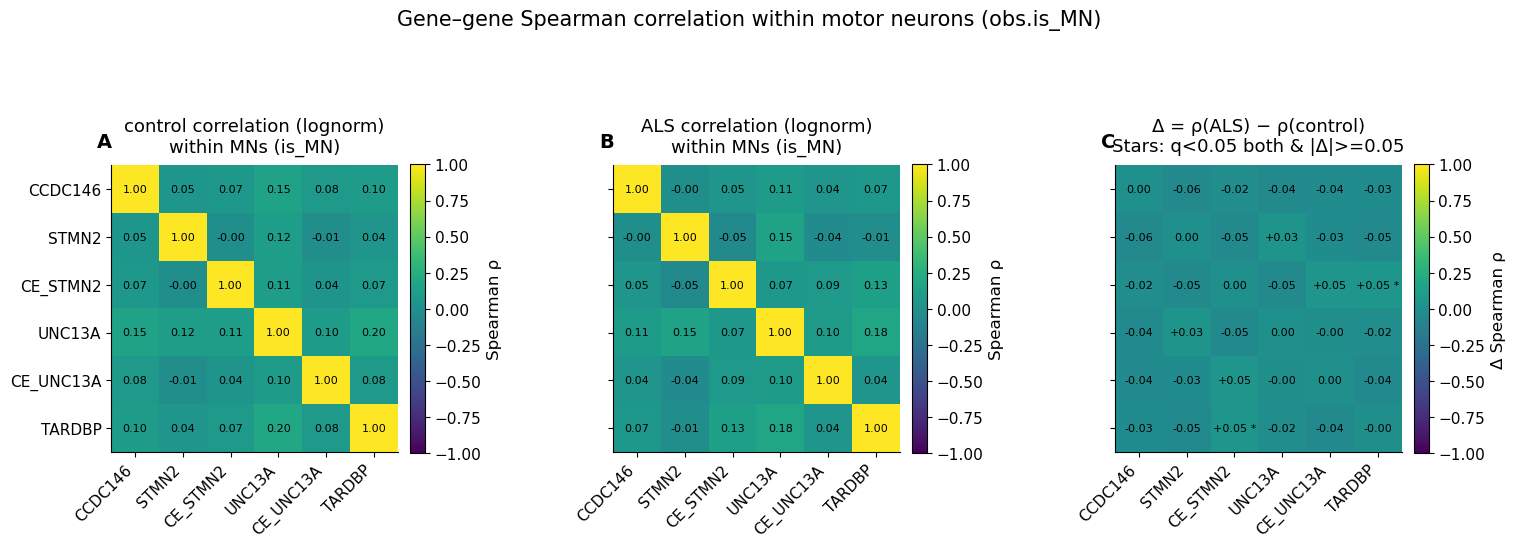

Saved figure: MNcorrected_MNcells_geneCorr_secondary.png
Saved figure: MNcorrected_MNcells_geneCorr_secondary.pdf


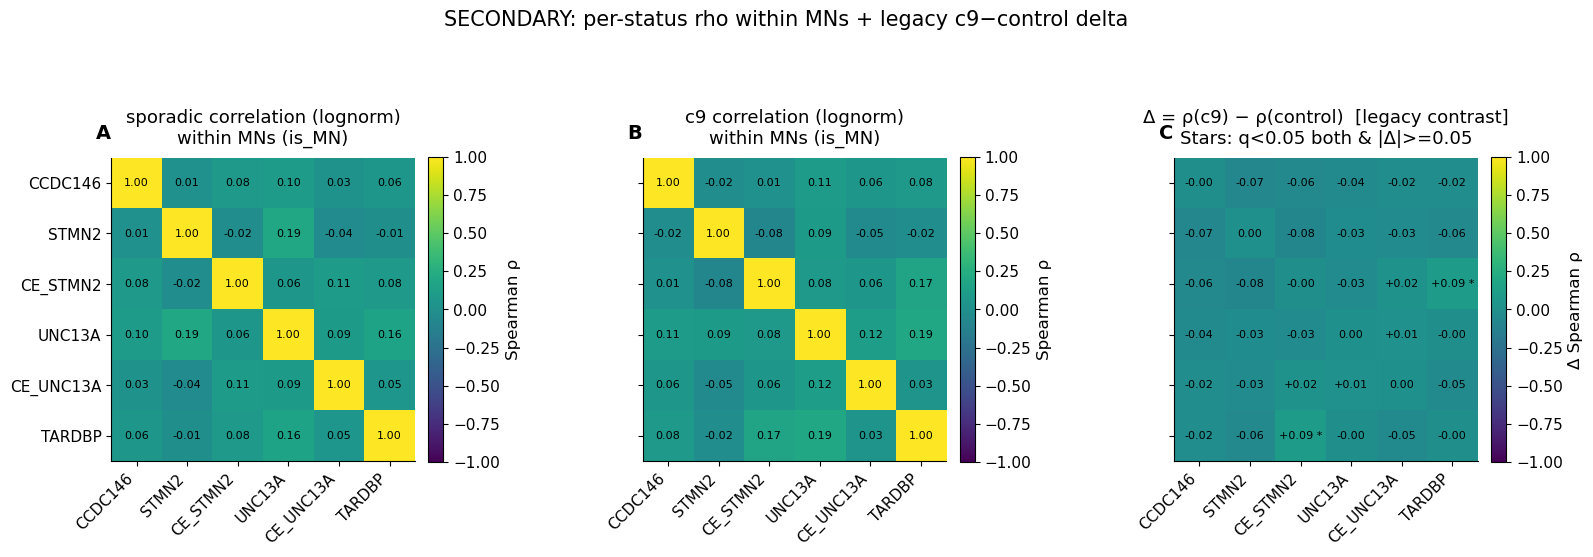

Saved combined correlation CSV: MNcorrected_MNcells_geneCorr_correlations.csv
Saved p-values CSV: MNcorrected_MNcells_geneCorr_pvalues.csv
Saved heatmap-only CSV: MNcorrected_MNcells_geneCorr_heatmap_correlations.csv


In [4]:
# ============================================================================
# THE HEATMAP CELL — Spearman gene-gene correlation WITHIN actual MNs (is_MN),
# per status group, with BH-FDR, the (ALS - control) delta, stars, figures,
# and combined / p-value / heatmap-only CSV exports.
#
# Legacy machinery (as1d, resolve_gene, get_vec_from_layer, bh_fdr, mat_from,
# draw_heat, the both-groups q<0.05 & |Delta|>=0.05 star rule, the n>=30 min-n
# guard, nanstd>0 guard) is reused verbatim. The ONLY substantive change vs the
# legacy gated cell: the cell subset is `is_MN` intersected with each status
# group's mask, NOT the STMN2 top-30% gate.
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------
# Parameters (flip these to re-slice)
# -----------------------------
STATUS_GROUPS = {
    "control":  ["control"],
    "ALS":      ["sporadic", "c9"],
    "sporadic": ["sporadic"],
    "c9":       ["c9"],
}
DELTA_PAIR = ("ALS", "control")          # PRIMARY (abstract-aligned): positive Delta = stronger in ALS
LEGACY_DELTA_PAIR = ("c9", "control")    # legacy-faithful contrast; ALSO computed + drawn (secondary fig)
PRIMARY_GROUPS = ["control", "ALS"]      # headline heatmaps (+ their delta)
SECONDARY_GROUPS = ["sporadic", "c9"]    # completeness panels

status_col = "status"
min_n = 30
corr_genes = ["CCDC146", "STMN2", "CE_STMN2", "UNC13A", "CE_UNC13A", "TARDBP"]

out_prefix = "MNcorrected_MNcells_geneCorr"
primary_png = out_prefix + "_primary.png"
primary_pdf = out_prefix + "_primary.pdf"
secondary_png = out_prefix + "_secondary.png"
secondary_pdf = out_prefix + "_secondary.pdf"
corr_csv = out_prefix + "_correlations.csv"
pval_csv = out_prefix + "_pvalues.csv"
heatmap_csv = out_prefix + "_heatmap_correlations.csv"

font_size = 12

# -----------------------------
# Helpers (verbatim from legacy)
# -----------------------------
def as1d(a):
    if hasattr(a, "toarray"):
        return np.asarray(a.toarray()).ravel()
    return np.asarray(a).ravel()

def resolve_gene(name, adata, aliases=None):
    if aliases and name in aliases:
        name = aliases[name]
    var = adata.var_names
    var_upper = var.str.upper()
    hits = np.where(var_upper == name.upper())[0]
    if len(hits) >= 1:
        return var[hits[0]]
    subs = [g for g in var if name.upper() in g.upper()]
    if len(subs) >= 1:
        subs_sorted = sorted(subs, key=lambda g: (len(g), g))
        return subs_sorted[0]
    return None

ALIASES = {"TDP-43": "TARDBP"}

def get_vec_from_layer(adata, gene, layer, aliases=None, dtype=np.float32):
    g = resolve_gene(gene, adata, aliases=aliases)
    if g is None:
        return None, None
    view = adata[:, g]
    if layer not in view.layers:
        raise ValueError(f"Layer '{layer}' not found in adata.layers.")
    v = as1d(view.layers[layer])
    if dtype is not None:
        v = v.astype(dtype, copy=False)
    return g, v

def get_counts_vec(adata, gene):
    return get_vec_from_layer(adata, gene, layer="counts", aliases=ALIASES, dtype=np.int32)

def get_lognorm_vec(adata, gene):
    return get_vec_from_layer(adata, gene, layer="lognorm", aliases=ALIASES, dtype=np.float32)

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q
    pv = p[ok]
    n = pv.size
    order = np.argsort(pv)
    ranked = pv[order]
    qv = ranked * n / (np.arange(n) + 1)
    qv = np.minimum.accumulate(qv[::-1])[::-1]
    qv = np.clip(qv, 0, 1)
    out = np.empty_like(pv)
    out[order] = qv
    q[ok] = out
    return q

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def panel_letter(ax, letter, fs=None):
    if fs is None:
        fs = font_size + 2
    ax.text(-0.05, 1.05, letter, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=fs, fontweight="bold")

# -----------------------------
# MN mask x status-group masks (THE substantive change vs legacy)
# -----------------------------
mn_mask = adata.obs["is_MN"].values.astype(bool)
status_series = adata.obs[status_col].astype(str).str.lower().to_numpy()

group_masks = {}
for gname, members in STATUS_GROUPS.items():
    members_l = [m.lower() for m in members]
    smask = np.isin(status_series, members_l)
    group_masks[gname] = mn_mask & smask
print("total MNs:", int(mn_mask.sum()))
print("MN n per group:", {g: int(m.sum()) for g, m in group_masks.items()})

# -----------------------------
# Gene vectors (lognorm for corr, counts for nonzero fractions)
# -----------------------------
corr_logn = {}
corr_cnts = {}
missing = []
for g in corr_genes:
    _, v = get_lognorm_vec(adata, g)
    if v is None:
        missing.append(g)
        continue
    corr_logn[g] = v
    _, vc = get_counts_vec(adata, g)
    corr_cnts[g] = vc
if missing:
    print("WARNING: missing corr genes (skipped):", missing)
genes = [g for g in corr_genes if g in corr_logn]
gix = {g: i for i, g in enumerate(genes)}

# -----------------------------
# Per-group: print n + nonzero fraction, then build corr_df (all groups)
# -----------------------------
corr_rows = []
for gname, gmask in group_masks.items():
    n_in = int(gmask.sum())
    print(f"\n=== group '{gname}'  (status in {STATUS_GROUPS[gname]}) ===")
    print(f"  n MN cells: {n_in}")
    for g in genes:
        nzf = float(np.mean(corr_cnts[g][gmask] >= 1)) if n_in > 0 else np.nan
        print(f"    {g:12s} nonzero fraction (counts>=1): {nzf:.4f}")
    for gi in genes:
        for gj in genes:
            xi = corr_logn[gi][gmask]
            xj = corr_logn[gj][gmask]
            if n_in >= min_n and np.isfinite(xi).all() and np.isfinite(xj).all() and (np.nanstd(xi) > 0) and (np.nanstd(xj) > 0):
                rho, p = spearmanr(xi, xj)
            else:
                rho, p = np.nan, np.nan
            corr_rows.append({"status": gname, "gene_i": gi, "gene_j": gj, "rho": rho, "p": p})
corr_df = pd.DataFrame(corr_rows)

# BH-FDR on the UPPER-TRIANGLE p-values PER group, mirrored to lower triangle.
corr_df["q"] = np.nan
for gname in STATUS_GROUPS:
    sub = corr_df[corr_df["status"] == gname].copy()
    is_upper = sub.apply(lambda r: gix[r["gene_i"]] < gix[r["gene_j"]], axis=1).values
    qvals = bh_fdr(sub.loc[is_upper, "p"].values)
    tmp = sub.loc[is_upper, ["gene_i", "gene_j"]].copy()
    tmp["q"] = qvals
    for _, r in tmp.iterrows():
        gi, gj, qv = r["gene_i"], r["gene_j"], r["q"]
        corr_df.loc[(corr_df["status"] == gname) & (corr_df["gene_i"] == gi) & (corr_df["gene_j"] == gj), "q"] = qv
        corr_df.loc[(corr_df["status"] == gname) & (corr_df["gene_i"] == gj) & (corr_df["gene_j"] == gi), "q"] = qv

def mat_from(status):
    mat = np.full((len(genes), len(genes)), np.nan, dtype=float)
    qmat = np.full_like(mat, np.nan, dtype=float)
    sub = corr_df[corr_df["status"] == status]
    for _, r in sub.iterrows():
        i, j = gix[r["gene_i"]], gix[r["gene_j"]]
        mat[i, j] = r["rho"]
        qmat[i, j] = r["q"]
    return mat, qmat

# -----------------------------
# Delta + stars. Compute BOTH the primary (ALS - control, abstract-aligned) and
# the legacy-faithful (c9 - control) deltas, so this notebook is a strict
# superset of the legacy c9-vs-control result rather than a substitution.
# -----------------------------
def delta_and_star(pairA, pairB):
    mA, qa = mat_from(pairA)
    mB, qb = mat_from(pairB)
    d = mA - mB
    s = (qa < 0.05) & (qb < 0.05) & (np.abs(d) >= 0.05)
    np.fill_diagonal(s, False)                 # diagonal never starred
    return mA, qa, mB, qb, d, s

grpA, grpB = DELTA_PAIR
mat_A, q_A, mat_B, q_B, delta_mat, sig_star = delta_and_star(grpA, grpB)
sig_star_primary = sig_star                    # stable ref (global sig_star is rebound below)

lgA, lgB = LEGACY_DELTA_PAIR
mat_lgA, q_lgA, mat_lgB, q_lgB, delta_legacy, sig_star_legacy = delta_and_star(lgA, lgB)

# -----------------------------
# draw_heat (verbatim from legacy; uses globals genes, sig_star, fig)
# -----------------------------
def draw_heat(ax, mat, title, letter, ylabel=True, star=False):
    panel_letter(ax, letter)
    im = ax.imshow(mat, vmin=-1, vmax=1, aspect="equal")
    ax.set_xticks(np.arange(len(genes)))
    ax.set_yticks(np.arange(len(genes)))
    ax.set_xticklabels(genes, rotation=45, ha="right")
    ax.set_yticklabels(genes if ylabel else [])
    ax.set_title(title, pad=10)
    despine(ax)
    for i in range(len(genes)):
        for j in range(len(genes)):
            if not np.isfinite(mat[i, j]):
                continue
            if star and (i != j):
                txt = f"{mat[i,j]:+.2f}"
                if sig_star[i, j]:
                    txt += " *"
            else:
                txt = f"{mat[i,j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Spearman ρ" if not star else "Δ Spearman ρ")

plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size + 1,
    "axes.labelsize": font_size,
    "xtick.labelsize": font_size - 1,
    "ytick.labelsize": font_size - 1,
    "legend.fontsize": font_size - 1,
})

# -----------------------------
# PRIMARY figure: control | ALS | Delta(ALS - control)
# (group panels drawn star=False like legacy B/C; stars only on the delta panel)
# -----------------------------
fig = plt.figure(figsize=(17, 5.6))
gs = fig.add_gridspec(1, 3, wspace=0.6)

axB = fig.add_subplot(gs[0, 0])
draw_heat(axB, mat_from(grpB)[0], f"{grpB} correlation (lognorm)\nwithin MNs (is_MN)", "A", ylabel=True, star=False)

axC = fig.add_subplot(gs[0, 1])
draw_heat(axC, mat_from(grpA)[0], f"{grpA} correlation (lognorm)\nwithin MNs (is_MN)", "B", ylabel=False, star=False)

axD = fig.add_subplot(gs[0, 2])
draw_heat(axD, delta_mat, f"Δ = ρ({grpA}) − ρ({grpB})\nStars: q<0.05 both & |Δ|>=0.05", "C", ylabel=False, star=True)

fig.suptitle("Gene–gene Spearman correlation within motor neurons (obs.is_MN)", y=1.03, fontsize=font_size + 3)
fig.savefig(primary_png, dpi=300, bbox_inches="tight")
fig.savefig(primary_pdf, dpi=300, bbox_inches="tight")
print(f"Saved figure: {primary_png}")
print(f"Saved figure: {primary_pdf}")
plt.show()

# -----------------------------
# SECONDARY figure (completeness): sporadic | c9 rho matrices (no headline contrast)
# `fig` is rebound so the verbatim draw_heat attaches colorbars to this figure.
# -----------------------------
sec_groups = [g for g in SECONDARY_GROUPS if g in STATUS_GROUPS]
n_sec = len(sec_groups) + 1                       # + the legacy (c9 - control) delta panel
fig = plt.figure(figsize=(6.0 * max(n_sec, 1), 5.6))
gs = fig.add_gridspec(1, max(n_sec, 1), wspace=0.6)
for k, gname in enumerate(sec_groups):
    ax = fig.add_subplot(gs[0, k])
    draw_heat(ax, mat_from(gname)[0], f"{gname} correlation (lognorm)\nwithin MNs (is_MN)",
              chr(ord("A") + k), ylabel=(k == 0), star=False)
# Legacy-faithful delta panel — reproduces the legacy c9-vs-control starred contrast.
# draw_heat reads the module-global `sig_star`, so point it at the legacy stars here.
sig_star = sig_star_legacy
ax = fig.add_subplot(gs[0, len(sec_groups)])
draw_heat(ax, delta_legacy, f"Δ = ρ({lgA}) − ρ({lgB})  [legacy contrast]\nStars: q<0.05 both & |Δ|>=0.05",
          chr(ord("A") + len(sec_groups)), ylabel=False, star=True)
fig.suptitle("SECONDARY: per-status rho within MNs + legacy c9−control delta", y=1.03, fontsize=font_size + 3)
fig.savefig(secondary_png, dpi=300, bbox_inches="tight")
fig.savefig(secondary_pdf, dpi=300, bbox_inches="tight")
print(f"Saved figure: {secondary_png}")
print(f"Saved figure: {secondary_pdf}")
plt.show()

# ============================================================================
# CSV exports (cover every group in STATUS_GROUPS; delta/star for DELTA_PAIR)
# ============================================================================
# Per-pair delta/star tables for BOTH the primary and legacy delta pairs.
_delta_specs = [
    (f"{grpA}_minus_{grpB}", mat_A, mat_B, q_A, q_B, delta_mat, sig_star_primary),
    (f"{lgA}_minus_{lgB}",   mat_lgA, mat_lgB, q_lgA, q_lgB, delta_legacy, sig_star_legacy),
]
delta_rows = []
for _dp_name, _mA, _mB, _qA, _qB, _dmat, _sstar in _delta_specs:
    for gi in genes:
        for gj in genes:
            i, j = gix[gi], gix[gj]
            delta_rows.append({
                "delta_pair": _dp_name,
                "gene_i": gi, "gene_j": gj,
                "rho_group_a": _mA[i, j],
                "rho_group_b": _mB[i, j],
                "delta_rho": _dmat[i, j],
                "q_group_a": _qA[i, j],
                "q_group_b": _qB[i, j],
                "star": bool(_sstar[i, j]) if i != j else False,
            })
delta_df = pd.DataFrame(delta_rows)

# 1) Combined correlation-matrix CSV (all groups + the delta/star block).
corr_out = corr_df.copy()
corr_out["analysis"] = "corr_matrix"
corr_out["mask"] = "is_MN"
delta_out = delta_df.copy()
delta_out["analysis"] = "delta"
delta_out["mask"] = "is_MN"
combined = pd.concat([corr_out, delta_out], ignore_index=True)
combined.to_csv(corr_csv, index=False)
print(f"Saved combined correlation CSV: {corr_csv}")

# 2) P-values CSV (one row per gene pair / group), mirroring legacy corr_p.
pval_df = corr_df.copy()
pval_df["analysis"] = "corr_matrix"
pval_df["mask"] = "is_MN"
pval_df = pval_df[[
    "analysis", "mask", "status", "gene_i", "gene_j", "rho", "p", "q",
]].rename(columns={"p": "p_value", "rho": "effect_spearman_rho"})
pval_df.to_csv(pval_csv, index=False)
print(f"Saved p-values CSV: {pval_csv}")

# 3) Heatmap-only CSV (upper triangle, all groups) — mirrors legacy cell 9.
heatmap_df = corr_df.copy()
heatmap_df["analysis"] = "heatmap_correlation"
heatmap_df["mask"] = "is_MN"
heatmap_df = heatmap_df[
    heatmap_df.apply(lambda r: gix[r["gene_i"]] < gix[r["gene_j"]], axis=1)
].copy()
heatmap_df = heatmap_df[[
    "analysis", "mask", "status", "gene_i", "gene_j", "rho", "p", "q",
]]
heatmap_df.to_csv(heatmap_csv, index=False)
print(f"Saved heatmap-only CSV: {heatmap_csv}")


   gene status_group  n_MN  n_nonMN  detect_rate_MN  detect_rate_nonMN  fisher_OR_MN_vs_nonMN      fisher_p
CCDC146      control  8579   916265        0.117962           0.014534               9.068034  0.000000e+00
CCDC146          ALS  2621   958161        0.080122           0.016520               5.185284  8.658427e-76
CCDC146     sporadic  1325   535437        0.092830           0.019420               5.167047  8.338777e-45
CCDC146           c9  1296   422724        0.067130           0.012848               5.529098  1.432615e-34
   MNX1      control  8579   916265        0.031822           0.004554               7.183912 8.856804e-130
   MNX1          ALS  2621   958161        0.056085           0.005307              11.136641  1.258058e-95
   MNX1     sporadic  1325   535437        0.066415           0.006075              11.638331  2.256094e-59
   MNX1           c9  1296   422724        0.045525           0.004334              10.957905  3.500046e-39
   BCL6      control  8579  

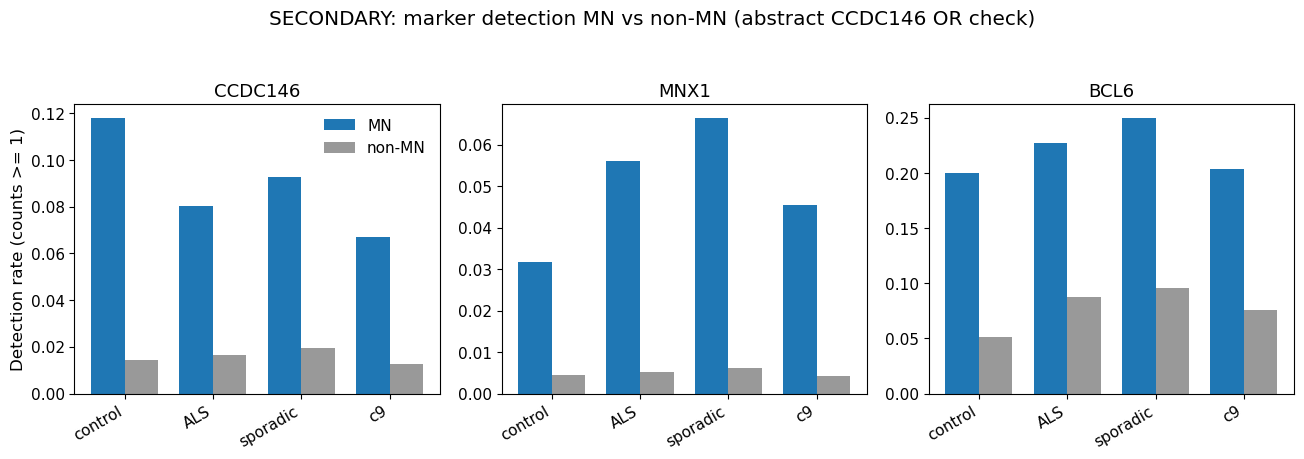

In [5]:
# ============================================================================
# SECONDARY / ABSTRACT CHECK (clearly labelled; NOT the headline heatmaps):
# CCDC146 (and MNX1, BCL6) detection rate in MN vs non-MN, by status group,
# with Fisher exact OR + p. This is the Panel-A analogue and reproduces the
# abstract's "CCDC146 enriched in motor neurons" odds-ratio result.
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

enrich_genes = ["CCDC146", "MNX1", "BCL6"]
detect_min_counts = 1

mn_mask = adata.obs["is_MN"].values.astype(bool)
status_series = adata.obs[status_col].astype(str).str.lower().to_numpy()

enrich_rows = []
for g in enrich_genes:
    gg = resolve_gene(g, adata, aliases=ALIASES)
    if gg is None:
        print("skip missing gene:", g)
        continue
    _, vc = get_counts_vec(adata, g)
    pos = vc >= detect_min_counts
    for gname, members in STATUS_GROUPS.items():
        members_l = [m.lower() for m in members]
        smask = np.isin(status_series, members_l)
        mn_in = smask & mn_mask
        non_in = smask & (~mn_mask)
        a_pos = int((pos & mn_in).sum()); a_neg = int((~pos & mn_in).sum())
        b_pos = int((pos & non_in).sum()); b_neg = int((~pos & non_in).sum())
        if (a_pos + a_neg) > 0 and (b_pos + b_neg) > 0:
            or_, p = fisher_exact([[a_pos, a_neg], [b_pos, b_neg]])
        else:
            or_, p = np.nan, np.nan
        enrich_rows.append({
            "gene": gg,
            "status_group": gname,
            "n_MN": a_pos + a_neg,
            "n_nonMN": b_pos + b_neg,
            "detect_rate_MN": a_pos / max(a_pos + a_neg, 1),
            "detect_rate_nonMN": b_pos / max(b_pos + b_neg, 1),
            "fisher_OR_MN_vs_nonMN": float(or_),
            "fisher_p": float(p),
        })
enrich_df = pd.DataFrame(enrich_rows)
print(enrich_df.to_string(index=False))

enrich_csv = "MNcorrected_MNcells_geneCorr_MNenrichment_detection.csv"
enrich_df.to_csv(enrich_csv, index=False)
print("Saved:", enrich_csv)

# Bar plot: MN vs non-MN detection rate, per gene, across status groups.
plot_groups = [g for g in ["control", "ALS", "sporadic", "c9"] if g in STATUS_GROUPS]
fig = plt.figure(figsize=(4.4 * len(enrich_genes), 4.4))
for gi, g in enumerate(enrich_genes):
    ax = fig.add_subplot(1, len(enrich_genes), gi + 1)
    sub = enrich_df[enrich_df["gene"].str.upper() == g.upper()]
    x = np.arange(len(plot_groups))
    w = 0.38
    mn_vals = [float(sub[sub["status_group"] == gr]["detect_rate_MN"].iloc[0]) if (sub["status_group"] == gr).any() else np.nan for gr in plot_groups]
    non_vals = [float(sub[sub["status_group"] == gr]["detect_rate_nonMN"].iloc[0]) if (sub["status_group"] == gr).any() else np.nan for gr in plot_groups]
    ax.bar(x - w / 2, mn_vals, width=w, label="MN", color="tab:blue")
    ax.bar(x + w / 2, non_vals, width=w, label="non-MN", color="0.6")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_groups, rotation=30, ha="right")
    ax.set_title(g)
    if gi == 0:
        ax.set_ylabel(f"Detection rate (counts >= {detect_min_counts})")
        ax.legend(frameon=False)
fig.suptitle("SECONDARY: marker detection MN vs non-MN (abstract CCDC146 OR check)", y=1.04)
fig.tight_layout()
fig.savefig("MNcorrected_MNcells_geneCorr_MNenrichment_detection.png", dpi=300, bbox_inches="tight")
fig.savefig("MNcorrected_MNcells_geneCorr_MNenrichment_detection.pdf", dpi=300, bbox_inches="tight")
print("Saved: MNcorrected_MNcells_geneCorr_MNenrichment_detection.png / .pdf")
plt.show()


## Nature-tier dotplot — top-10 MN genes + MNX1 / STMN2

Top-10 genes characterising the motor neurons, with the canonical markers **MNX1** and **STMN2** appended (bracketed) to check their expression and detection. Requires cells 1-3 to have run (object loaded; `counts` + `lognorm` layers built).

- `RANK_MODE="markers"` (default): top-10 by **MN-vs-non-MN** differential expression (Wilcoxon on `lognorm`).
- `RANK_MODE="mean_expr"`: top-10 by **mean lognorm expression within MNs**.
- `GROUPBY_MODE`: `"mn_vs_nonmn"` (default; shows the markers separate MNs from the rest) or `"status_within_mn"` (MNs split control/sporadic/c9).

*Circularity note:* `is_MN` was defined partly from STMN2 / MNX1 / morphology, so their appearance among the top MN markers is expected by construction — this panel is descriptive of the label, not an independent marker discovery.


Top 20 MN markers (MN vs non-MN, Wilcoxon): ['STMN2', 'SNCG', 'APP', 'KIF5A', 'SOD1', 'CTSD', 'DNER', 'TUBA4A', 'SV2C', 'GRB2', 'LAMP5', 'CTSB', 'VCP', 'OPTN', 'CABP1', 'SLC1A2', 'FUS', 'NIPA1', 'KCNQ2', 'TARDBP']
Saved: MNcorrected_MNmarkers_top10.csv
NOTE: marker(s) already in top list: ['STMN2']
Genes plotted: ['STMN2', 'SNCG', 'APP', 'KIF5A', 'SOD1', 'CTSD', 'DNER', 'TUBA4A', 'SV2C', 'GRB2', 'LAMP5', 'CTSB', 'VCP', 'OPTN', 'CABP1', 'SLC1A2', 'FUS', 'NIPA1', 'KCNQ2', 'TARDBP', 'MNX1']
Saved: MNcorrected_MNmarkers_dotplot.png and MNcorrected_MNmarkers_dotplot.pdf


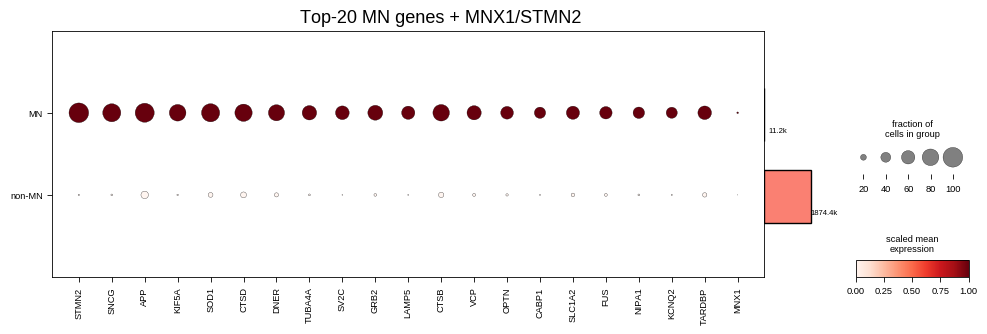

In [11]:
# ============================================================================
# NATURE-TIER DOTPLOT — top-10 MN genes + canonical markers MNX1 & STMN2.
# Requires cells 1-3 (adata loaded; 'counts' + 'lognorm' layers built).
# ============================================================================
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N_TOP = 20
MARKERS = ["MNX1", "STMN2"]          # canonical MN markers appended to check expression
RANK_MODE = "markers"                 # "markers" (MN-vs-non-MN Wilcoxon) | "mean_expr" (top mean lognorm in MNs)
GROUPBY_MODE = "mn_vs_nonmn"          # "mn_vs_nonmn" | "status_within_mn"
STANDARD_SCALE = "var"                # per-gene 0-1 scaling for comparable dot colour; None = raw mean lognorm

out_png = "MNcorrected_MNmarkers_dotplot.png"
out_pdf = "MNcorrected_MNmarkers_dotplot.pdf"
out_top_csv = "MNcorrected_MNmarkers_top10.csv"

mn_mask = adata.obs["is_MN"].values.astype(bool)
adata.obs["mn_group"] = np.where(mn_mask, "MN", "non-MN")
adata.obs["mn_group"] = adata.obs["mn_group"].astype("category")

# -----------------------------
# Rank the top-N MN genes
# -----------------------------
if RANK_MODE == "mean_expr":
    Xln = adata.layers["lognorm"][mn_mask]
    means = np.asarray(Xln.mean(axis=0)).ravel()
    order = np.argsort(means)[::-1]
    top_mn = [str(adata.var_names[i]) for i in order[:N_TOP]]
    top_df = pd.DataFrame({"gene": top_mn,
                           "mean_lognorm_in_MN": [float(means[i]) for i in order[:N_TOP]]})
    print(f"Top {N_TOP} genes by mean lognorm within MNs:", top_mn)
else:  # "markers"
    sc.tl.rank_genes_groups(
        adata, groupby="mn_group", groups=["MN"], reference="non-MN",
        method="wilcoxon", use_raw=False, layer="lognorm",
    )
    rg = adata.uns["rank_genes_groups"]
    top_mn = [str(g) for g in rg["names"]["MN"][:N_TOP]]
    top_df = pd.DataFrame({
        "gene": top_mn,
        "logfoldchange": [float(x) for x in rg["logfoldchanges"]["MN"][:N_TOP]],
        "pval_adj": [float(x) for x in rg["pvals_adj"]["MN"][:N_TOP]],
        "score": [float(x) for x in rg["scores"]["MN"][:N_TOP]],
    })
    print(f"Top {N_TOP} MN markers (MN vs non-MN, Wilcoxon):", top_mn)

top_df.to_csv(out_top_csv, index=False)
print("Saved:", out_top_csv)

# -----------------------------
# Genes to plot: top-N + appended markers (dedup); bracket the appended markers
# -----------------------------
extra = [m for m in MARKERS if (m in adata.var_names) and (m not in top_mn)]
already = [m for m in MARKERS if m in top_mn]
if already:
    print("NOTE: marker(s) already in top list:", already)
genes_to_plot = top_mn + extra
print("Genes plotted:", genes_to_plot)

#var_group_positions = [(len(top_mn), len(genes_to_plot) - 1)] if extra else None
#var_group_labels = ["canonical\nMN markers"] if extra else None

# -----------------------------
# Plot group axis
# -----------------------------
if GROUPBY_MODE == "status_within_mn":
    ad_plot = adata[mn_mask].copy()
    order_s = [s for s in ["control", "sporadic", "c9"] if s in set(ad_plot.obs["status"].astype(str))]
    ad_plot.obs["dot_group"] = ad_plot.obs["status"].astype(str).astype("category").cat.reorder_categories(order_s)
    groupby = "dot_group"
    n_groups = len(order_s)
    title = f"Top-{N_TOP} MN genes + MNX1/STMN2"
else:
    ad_plot = adata
    groupby = "mn_group"
    n_groups = 2
    title = f"Top-{N_TOP} MN genes + MNX1/STMN2"

# -----------------------------
# Nature-tier rcParams (editable text, thin spines, sans-serif)
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 8, "axes.linewidth": 0.6,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
})

dp = sc.pl.dotplot(
    ad_plot, genes_to_plot, groupby=groupby, layer="lognorm", use_raw=False,
    standard_scale=STANDARD_SCALE, cmap="Reds", dendrogram=False,
    #var_group_positions=var_group_positions, var_group_labels=var_group_labels,
    colorbar_title=("scaled mean\nexpression" if STANDARD_SCALE == "var" else "mean expr\n(lognorm)"),
    size_title="fraction of\ncells in group",
    title=title,
    figsize=(0.42 * len(genes_to_plot) + 3.0, 0.5 * n_groups + 2.2),
    return_fig=True, show=False,
)
try:
    dp.add_totals()      # per-group cell-count bar (cosmetic nature touch)
except Exception as _e:
    print("add_totals skipped:", _e)

# DotPlot.fig is lazy -> materialise with make_figure() before saving (see build notes).
dp.make_figure()
fig = getattr(dp, "fig", None) or plt.gcf()
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
print("Saved:", out_png, "and", out_pdf)
plt.show()
